In [1]:
import odc.stac
import pyproj
import pystac_client
from shapely.geometry import box
from shapely.ops import transform

In [2]:
CMR_STAC_URL = "https://cmr.earthdata.nasa.gov/stac/LPCLOUD"

catalog = pystac_client.Client.open(CMR_STAC_URL)

HLS_COLLECTION_IDS = ["HLSL30_2.0", "HLSS30_2.0"]

In [3]:
# my CRS of choice for CONUS these days
CRS_STRING = "epsg:5070"
EPSG = pyproj.CRS.from_string(CRS_STRING).to_epsg()

# Some nice fall dates
START_DATE = "2024-09-15"
END_DATE = "2024-10-08"

# bounding box that surrounds the North Shore of Lake Superior
bbox = (373926, 2744693, 406338, 2765304)
aoi = box(*bbox)

# STAC items store bounding box info in epsg:4326
transformer_4326 = pyproj.Transformer.from_crs(
    crs_from=CRS_STRING,
    crs_to="epsg:4326",
    always_xy=True,
)

bbox_4326 = transform(transformer_4326.transform, aoi).bounds

stac_items = catalog.search(
    collections=HLS_COLLECTION_IDS,
    bbox=bbox_4326,
    datetime=[START_DATE, END_DATE],
    limit=100,
).item_collection()

In [5]:
HLS_ODC_STAC_CONFIG = {
    "HLSL30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "data_type": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "data_type": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "nir_narrow": "B05",
            "swir_1": "B06",
            "swir_2": "B07",
            "cirrus": "B09",
            "thermal_infrared_1": "B10",
            "thermal": "B11",
        },
    },
    "HLSS30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "dtype": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "dtype": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "red_edge_1": "B05",
            "red_edge_2": "B06",
            "red_edge_3": "B07",
            "nir_broad": "B08",
            "nir_narrow": "B8A",
            "water_vapor": "B09",
            "cirrus": "B10",
            "swir_1": "B11",
            "swir_2": "B12",
        },
    },
}

# these are the ones that we are going to use
BANDS = ["red", "green", "blue", "Fmask"]

stack = odc.stac.load(
    stac_items,
    stac_cfg=HLS_ODC_STAC_CONFIG,
    bands=BANDS,
    crs=CRS_STRING,
    resolution=60,
    chunks={},  # <-- use Dask
    groupby="solar_day",
    x=(bbox[0], bbox[2]),
    y=(bbox[1], bbox[3]),
)
display(stack)

<xarray.Dataset> Size: 16MB
Dimensions:      (y: 345, x: 541, time: 12)
Coordinates:
  * y            (y) float64 3kB 2.765e+06 2.765e+06 ... 2.745e+06 2.745e+06
  * x            (x) float64 4kB 3.74e+05 3.74e+05 ... 4.063e+05 4.064e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 96B 2024-09-15T16:51:28.990000 ... 202...
Data variables:
    red          (time, y, x) int16 4MB dask.array<chunksize=(1, 345, 541), meta=np.ndarray>
    green        (time, y, x) int16 4MB dask.array<chunksize=(1, 345, 541), meta=np.ndarray>
    blue         (time, y, x) int16 4MB dask.array<chunksize=(1, 345, 541), meta=np.ndarray>
    Fmask        (time, y, x) uint8 2MB dask.array<chunksize=(1, 345, 541), meta=np.ndarray>

In [6]:
stack_ = stack.compute()

/home/henry/workspace/personal/hrodmn.dev/.venv/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


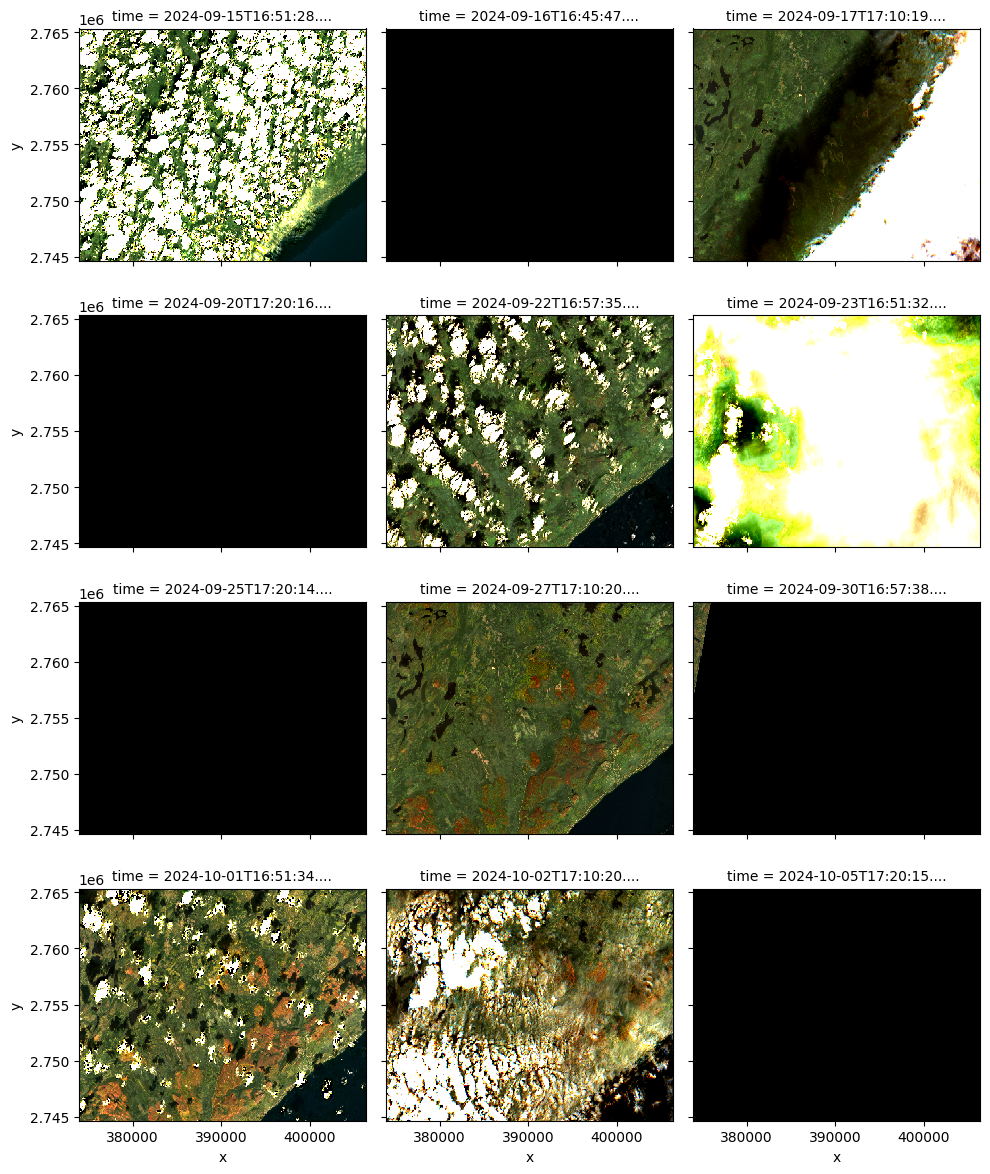

In [7]:
rgb = stack_.to_dataarray(dim="band").sel(band=["red", "green", "blue"])
rgb.plot.imshow(
    rgb="band",
    col="time",
    col_wrap=3,
    robust=True,
    vmin=0,
    vmax=1000,
)

In [8]:
def apply_gamma_correction(da, gamma=2.2, data_range=(0, 255)):
    """
    Apply gamma correction to an xarray DataArray containing RGB data.

    Parameters:
    - da: xarray DataArray with RGB data
    - gamma: gamma value (default 2.2)
    - data_range: tuple of (min, max) values in the data (default (0, 255))

    Returns:
    - xarray DataArray with gamma correction applied
    """
    # Ensure data is in float format
    da = da.astype(float)

    # Normalize data to 0-1 range
    da_normalized = (da - data_range[0]) / (data_range[1] - data_range[0])

    # Apply gamma correction
    da_corrected = da_normalized ** (1 / gamma)

    # Scale back to original range
    da_result = da_corrected * (data_range[1] - data_range[0]) + data_range[0]

    # Ensure we don't exceed the original data range
    da_result = da_result.clip(data_range[0], data_range[1])

    return da_result.astype(da.dtype)

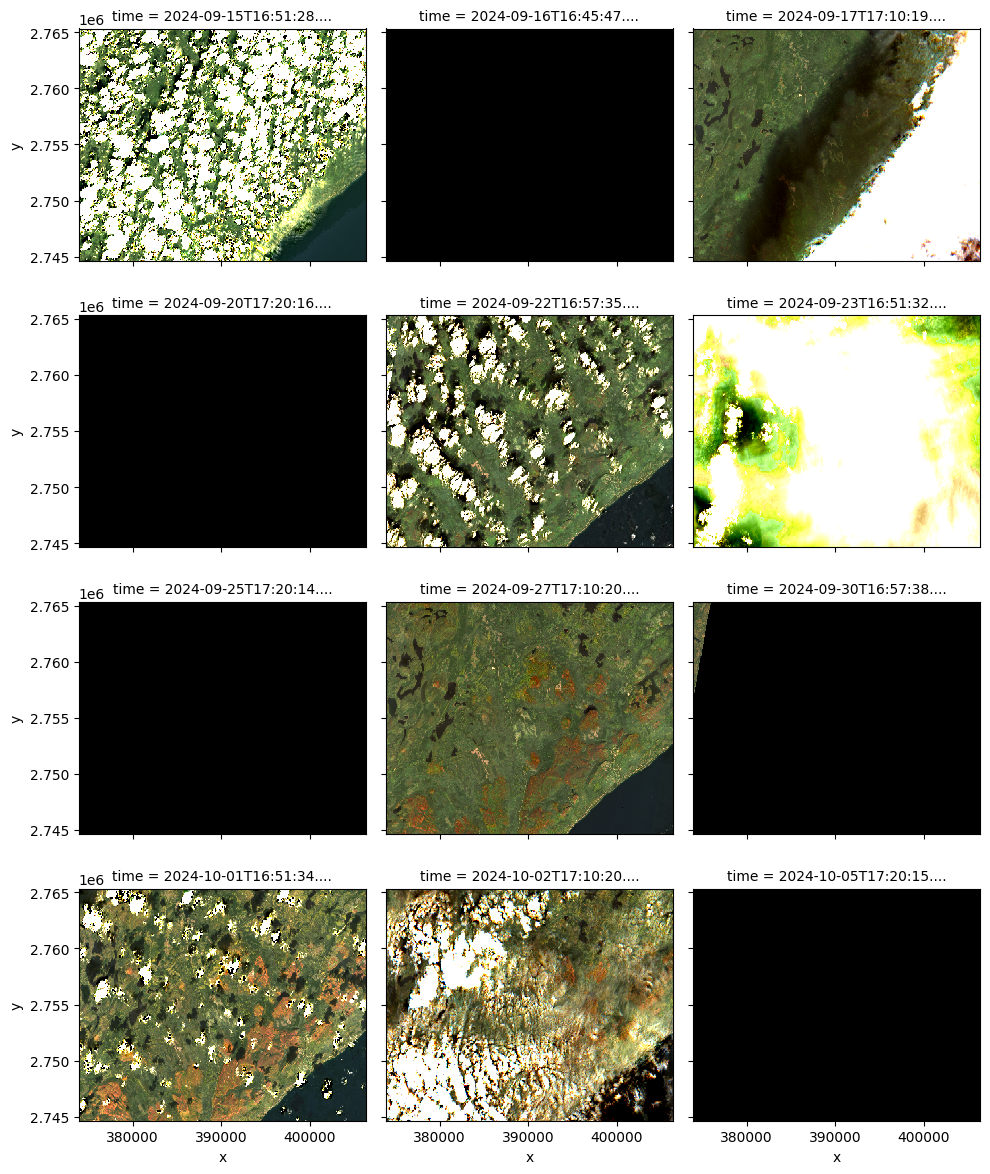

In [9]:
gamma_corrected = apply_gamma_correction(rgb, gamma=1.0, data_range=(-100, 1000))
gamma_corrected.plot.imshow(
    rgb="band",
    col="time",
    col_wrap=3,
    robust=True,
)

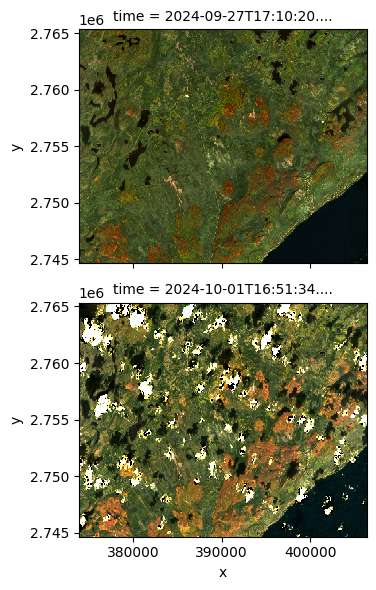

In [10]:
gamma_corrected.isel(time=[7, 9]).plot.imshow(
    rgb="band",
    row="time",
    robust=True,
    add_labels=False,
)